In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from MODELS.xgboostModel import *
from MODELS.ngboostModel import *
from PRODUCTION.pipeline import *

In [2]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


# Backtesting Training data
train_df = pd.concat([s21,s22,s23,s24,s25])
train_df = train_df[(train_df['MIN'] >= 10)]

# Backtesting Validation data
val_df = s26
val_df = val_df[(val_df['MIN'] >= 10)]


print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

train_df.sample(5)

/var/folders/9q/5_554qsx5z70w9d_vkmvjg0h0000gn/T/ipykernel_30065/256704780.py:10: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


Train set: 107776 samples
Val set: 4069 samples


,Unnamed: 0,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_3,AST_ROLLING_AVG_3,FGM_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FG_PCT_ROLLING_AVG_3,FG3M_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG3_PCT_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FTM_ROLLING_AVG_3,FT_PCT_ROLLING_AVG_3,TOV_ROLLING_AVG_3,TS_PCT_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,MIN_ROLLING_AVG_3,PACE_ROLLING_AVG_3,PIE_ROLLING_AVG_3,E_OFF_RATING_ROLLING_AVG_3,NET_RATING_ROLLING_AVG_3,TCHS_ROLLING_AVG_3,POSS_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,percentagePointsPaint_ROLLING_AVG_3,percentagePointsMidrange2pt_ROLLING_AVG_3,percentagePoints3pt_ROLLING_AVG_3,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_20,AST_ROLLING_AVG_2

In [ ]:
features = [
    # ===== CORE CONTEXT =====
    'HOME_GAME',
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',
    'OPP_STAR_OUT', #new
    'GAMES_PLAYED_TO_DATE',

    # ===== ROLLING AVERAGES =====
    'PTS_ROLLING_AVG_3', #new
    'PTS_ROLLING_AVG_5', 
    'PTS_ROLLING_AVG_10',
    'PTS_ROLLING_AVG_20', 
    'MIN_ROLLING_AVG_3', #new
    'MIN_ROLLING_AVG_5', 
    'MIN_ROLLING_AVG_10',
    'MIN_ROLLING_AVG_20', 
    'USG_PCT_ROLLING_AVG_3', #new
    'USG_PCT_ROLLING_AVG_5', 
    'USG_PCT_ROLLING_AVG_10',
    'USG_PCT_ROLLING_AVG_20',
    'TS_PCT_ROLLING_AVG_10',
    'TS_PCT_ROLLING_AVG_20', 
    'FGA_ROLLING_AVG_3', #new
    'FGA_ROLLING_AVG_5', 
    'FGA_ROLLING_AVG_10', 
    'FGA_ROLLING_AVG_20', 
    'FGM_ROLLING_AVG_10', #new
    'FGM_ROLLING_AVG_20', #new
    'FG_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_20', 
    'FG3M_ROLLING_AVG_3', #new
    'FG3A_ROLLING_AVG_5', 
    'FG3A_ROLLING_AVG_10', 
    'FG3A_ROLLING_AVG_20', 
    'FG3M_ROLLING_AVG_10', #new
    'FG3M_ROLLING_AVG_20', #new
    'FG3_PCT_ROLLING_AVG_10', 
    'FG3_PCT_ROLLING_AVG_20', 
    'FTA_ROLLING_AVG_5', 
    'FTA_ROLLING_AVG_10', 
    'FTA_ROLLING_AVG_20',
    'FTM_ROLLING_AVG_5', #new
    'FTM_ROLLING_AVG_10', #new
    'FTM_ROLLING_AVG_20', #new
    'FT_PCT_ROLLING_AVG_10', 
    'FT_PCT_ROLLING_AVG_20', 
    'E_OFF_RATING_ROLLING_AVG_5',
    'E_OFF_RATING_ROLLING_AVG_10',
    'E_OFF_RATING_ROLLING_AVG_20', 
    'NET_RATING_ROLLING_AVG_5', 
    'NET_RATING_ROLLING_AVG_10',
    'NET_RATING_ROLLING_AVG_20', 
    'PIE_ROLLING_AVG_20', #new

    # ===== LAG FEATURES =====
    'MIN_LAG_1',
    'PTS_LAG_1',
    'FGA_LAG_1',
    'USG_PCT_LAG_1',
    'POSS_LAG_1', #new
    'TS_PCT_LAG_1', #new
    'TCHS_LAG_1', #new
    
    # ===== VOLATILITY =====
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'MIN_VOLATILITY_20_TO_DATE', 
    'PTS_VOLATILITY_5_TO_DATE',
    'PTS_VOLATILITY_10_TO_DATE', 
    'PTS_VOLATILITY_20_TO_DATE', 
    'FGA_VOLATILITY_5_TO_DATE',
    'FGA_VOLATILITY_10_TO_DATE',
    'FGA_VOLATILITY_20_TO_DATE',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE', 
    'USG_PCT_CV_20_TO_DATE', 
    'TS_PCT_CV_10_TO_DATE',
    'TS_PCT_CV_20_TO_DATE', 
    'FG3A_VOLATILITY_5_TO_DATE',
    'FG3A_VOLATILITY_10_TO_DATE', 
    'FG3A_VOLATILITY_20_TO_DATE',
    'FG3_PCT_CV_10_TO_DATE',
    'FG3_PCT_CV_20_TO_DATE', 
    'FTA_VOLATILITY_5_TO_DATE',
    'FTA_VOLATILITY_10_TO_DATE', 
    'FTA_VOLATILITY_20_TO_DATE', 
    'FT_PCT_CV_10_TO_DATE',
    'FT_PCT_CV_20_TO_DATE', 
    'TOV_VOLATILITY_10_TO_DATE',
    'PACE_VOLATILITY_5_TO_DATE',
    'PACE_VOLATILITY_10_TO_DATE',
    'E_OFF_RATING_VOLATILITY_5_TO_DATE',
    'E_OFF_RATING_VOLATILITY_10_TO_DATE',
    'NET_RATING_VOLATILITY_5_TO_DATE',
    'NET_RATING_VOLATILITY_10_TO_DATE',
    'TCHS_ROLLING_AVG_5', 
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_5', 
    'TOV_ROLLING_AVG_10',

    # ===== MIN/MAX (Useful extremes) =====
    'MIN_MAX_LAST_10', 
    'MIN_MIN_LAST_10',
    'PTS_MIN_LAST_10',
    'PTS_MAX_LAST_10', #new
    'PTS_MIN_LAST_20', #new
    'PTS_MAX_LAST_20', #new
    'USG_PCT_MAX_LAST_10',
    'USG_PCT_MIN_LAST_10',
    'TS_PCT_MAX_LAST_10', #new
    'TS_PCT_MIN_LAST_10', #new
    'PTS_RANGE_10', 
    'USG_PCT_RANGE_10', 
    'TS_PCT_RANGE_10', 
    
    # ==== Short vs long term divergences =====
    'PTS_5G_VS_20G_RATIO', 
    'MIN_5G_VS_20G_RATIO', 
    'USG_PCT_5G_VS_20G_RATIO', 
    
    # === Consistency metrics =====
    'PTS_CONSISTENCY', 
    'MIN_CONSISTENCY',
    'USG_PCT_CONSISTENCY', 
    
    # === Variance stability metrics =====
    'VARIANCE_STABILITY',
    'MIN_VARIANCE_STABILITY', 
    'USG_PCT_VARIANCE_STABILITY', 
    'TS_PCT_VARIANCE_STABILITY', 
    
    # ===== TRENDS =====
    'PTS_TREND_LAST_5',
    'MIN_TREND_LAST_5',
    'PTS_TREND_LAST_10',
    'MIN_TREND_LAST_10',
    
    # ===== INTERACTIONS (Keep - your best features) =====
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'PTS_PER_MIN_X_USG',
    'USAGE_X_EFFICIENCY',
    'USAGE_X_MINUTES', #new
    'PTS_PER_POSSESSION',
    'B2B_X_MIN_LAST_5', #new
    'USG_PCT_X_STAR_SAT_OUT', #new
    'PTS_PER_36', #new
    
    # ===== SHOT PROFILE =====
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    '3PA_RATE',
    'PLAYER_FG3A_SHARE',
    'PTS_PER_SHOT', 
    
    # ===== STAR DYNAMICS =====
    'PTS_DELTA_STAR_OUT',
    'USG_PCT_DELTA_STAR_OUT',
    'MIN_DELTA_STAR_OUT', 
    'FGA_DELTA_STAR_OUT', 
    'TS_PCT_DELTA_STAR_OUT', #new
    'GAMES_WITH_STAR', #new
    
    # ===== STREAKS & TIERS =====
    'IS_LOW_SCORER',
    'IS_MEDIUM_SCORER',
    'IS_HIGH_SCORER', 
    
    # ===== TEAM CONTEXT =====
    'TEAM_PTS_ROLLING_AVG_3', 
    'TEAM_AST_ROLLING_AVG_3', #new
    'TEAM_OFF_RATING_ROLLING_AVG_3', 
    'TEAM_PACE_ROLLING_AVG_3', #new
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    
    # ===== OPPONENT =====
    'OPP_TEAM_DEF_RATING_ROLLING_AVG_5', #new
    'OPP_TEAM_PACE_ROLLING_AVG_5', #new
    'OPP_TOV_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE', #new
    'OPP_STL_AVG_TO_DATE', #new
    'OPP_GUARD_DEF_RATING',
    'OPP_FORWARD_DEF_RATING',
    'OPP_CENTER_DEF_RATING',
    
    # ===== MATCHUP INTERACTIONS =====
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    
    # ===== GAME CONTEXT =====
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_DIFFERENTIAL',
    
    # ===== HOME/AWAY & MATCHUP =====
    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PLAYER_HOME_TS_PCT_DELTA', #new
    'MATCHUP_PTS_DELTA', #new
    'MATCHUP_MIN_DELTA', #new
    'MATCHUP_USG_PCT_DELTA', #new
    'MATCHUP_TS_PCT_DELTA', #new
]
print(f"Enhanced features: {len(features)}")

Enhanced features: 137


In [4]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [5]:
# from MODELS.xgboostModel import *

# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=100,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

In [6]:
# from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, features, threshold=0.95)

REMOVED: MIN_LAG_1                      (corr with POSS_LAG_1: 0.988)
REMOVED: PTS_PER_36                     (corr with PTS_ROLLING_AVG_20: 0.987)
REMOVED: FGM_ROLLING_AVG_20             (corr with PTS_ROLLING_AVG_20: 0.985)
REMOVED: FGA_ROLLING_AVG_10             (corr with FGA_ROLLING_AVG_20: 0.985)
REMOVED: FGM_ROLLING_AVG_10             (corr with PTS_ROLLING_AVG_10: 0.983)
REMOVED: FG3A_ROLLING_AVG_10            (corr with FG3A_ROLLING_AVG_20: 0.982)
REMOVED: FTA_ROLLING_AVG_20             (corr with FTM_ROLLING_AVG_20: 0.981)
REMOVED: PTS_ROLLING_AVG_10             (corr with PTS_ROLLING_AVG_20: 0.980)
REMOVED: FTA_ROLLING_AVG_10             (corr with FTM_ROLLING_AVG_10: 0.980)
REMOVED: TCHS_ROLLING_AVG_5             (corr with TCHS_ROLLING_AVG_10: 0.976)
REMOVED: FTA_ROLLING_AVG_5              (corr with FTM_ROLLING_AVG_5: 0.976)
REMOVED: USG_PCT_ROLLING_AVG_10         (corr with USG_PCT_ROLLING_AVG_20: 0.975)
REMOVED: MIN_ROLLING_AVG_10             (corr with MIN_ROLLING_AVG_

### NGBOOST MODEL

SPLIT NGBOOST

In [7]:

mean_model, variance_model, cal_factor = fit_ngboost_split(
train_df,
val_df,
features,
target_col='PTS',
distribution=Normal,
player_col='PLAYER_ID',
recent_n=20,
recent_weight=2.0,
variance_recent_weight=1.0,
variance_lr=0.03,  
variance_max_depth=7,  
variance_n_estimators=1000,
variance_calibration_factor=3.97)


Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


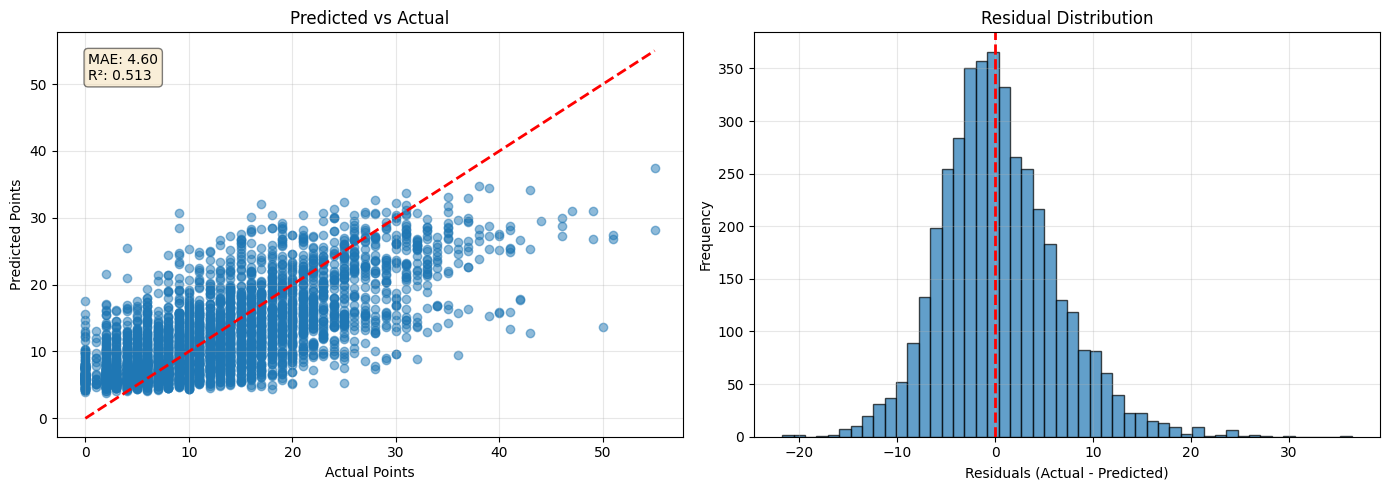

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

preds_dist = mean_model.pred_dist(val_df[features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = variance_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                      feature  mean_model
           FGA_ROLLING_AVG_20    0.043426
       TEAM_PTS_ROLLING_AVG_3    0.038419
              USAGE_X_MINUTES    0.032771
            FGA_ROLLING_AVG_3    0.032272
           PTS_ROLLING_AVG_20    0.031174
            PTS_PER_MIN_X_USG    0.031108
           FGA_ROLLING_AVG_10    0.029938
            FGA_ROLLING_AVG_5    0.027066
         OPP_GUARD_DEF_RATING    0.027045
       USG_PCT_X_STAR_SAT_OUT    0.025583
                     STARTING    0.024138
TEAM_DEF_RATING_ROLLING_AVG_3    0.021187
     USUAL_STARTERS_AVAILABLE    0.019797
           PTS_DELTA_STAR_OUT    0.018604
               IS_HIGH_SCORER    0.017339
           PTS_ROLLING_AVG_10    0.016069
       TEAM_AST_ROLLING_AVG_3    0.016012
                   PTS_PER_36    0.014296
              GAMES_WITH_STAR    0.014054
                IS_LOW_SCORER    0.013063


In [18]:
feature_importance_df = pd.DataFrame({
    'feature': features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('var_model', ascending=False)


print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                                feature  var_model
                     FGA_ROLLING_AVG_20   0.036278
                          IS_LOW_SCORER   0.034519
                     FGA_ROLLING_AVG_10   0.028935
                 TEAM_OFF_MINUS_OPP_DEF   0.018147
                   OPP_GUARD_DEF_RATING   0.014875
                       MIN_TREND_LAST_5   0.014859
                 TEAM_PTS_ROLLING_AVG_3   0.011892
                  PLAYER_HOME_PTS_DELTA   0.011355
                        USAGE_X_MINUTES   0.011156
                      PACE_DIFFERENTIAL   0.010505
              FGA_VOLATILITY_20_TO_DATE   0.010401
                    OPP_BLK_AVG_TO_DATE   0.010042
          TEAM_DEF_RATING_ROLLING_AVG_3   0.009854
         OPP_CENTER_PTS_ALLOWED_PER_MIN   0.009834
            OPP_TEAM_PACE_ROLLING_AVG_5   0.009796
                      FGA_ROLLING_AVG_5   0.009654
                TEAM_PACE_ROLLING_AVG_3   0.009607
          OPP_GUARD_PTS_ALLOWED

In [19]:
validate_production_model(mean_model, variance_model, val_df, features, 'PTS', cal_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: 0.041 (should be ~0)
Standardized residuals std: 1.007 (should be ~1)
Q25: Predicted=8.3, Actual=6.0
Q50: Predicted=12.2, Actual=11.0
Q75: Predicted=16.1, Actual=17.0

MAE: 4.60
90% CI: Coverage=90.78%, Expected=90.00%
95% CI: Coverage=95.01%, Expected=95.00%
99% CI: Coverage=98.43%, Expected=99.00%


array([-0.62047397,  1.01669621,  1.71005099, ...,  1.10425875,
       -0.09396369, -1.31492965], shape=(4069,))

In [20]:
import joblib

# # Save NGBoost split models (mean, variance, and calibration factor)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTION.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTION.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTION.pkl')

joblib.dump(features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']

In [13]:
# import joblib

# joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25v1.pkl')
# joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25v1.pkl')
# joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25v1.pkl')

# joblib.dump(features, 'SAVED_MODELS/feature_listv1.pkl')

In [14]:
# Cell removed


In [15]:
# Cell removed
